# 04 - Feature Engineering

---
Transform the labelled transaction data into a rich numeric feature matrix
ready for training.

**Input:** `data/processed/labelled_logs.csv`

**Output:** `data/processed/features.csv`


## 1. Imports and Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = sns.color_palette('muted')

RANDOM_SEED       = 42
HIGH_AMOUNT_THRESHOLD = 4000
RISKY_TYPES       = {'cashout', 'withdrawal', 'transfer'}
VELOCITY_WINDOWS  = ['1D', '7D', '30D']

INPUT_PATH  = Path('../data/processed/labelled_logs.csv')
OUTPUT_PATH = Path('../data/processed/features.csv')

print('Setup complete.')

Setup complete.


## 2. Load Labelled Data

Load from `labelled_logs.csv` produced by `03_label_simulation.ipynb`.
Sort by `user_id + timestamp`, this ordering is mandatory for all
sequential and rolling operations that follow.

In [2]:
df = pd.read_csv(INPUT_PATH, parse_dates=['timestamp'])

# Mandatory sort for sequential feature calculations
df = df.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

print('Shape   :', df.shape)
print('Columns :', list(df.columns))
print()
print('Label distribution:')
print(df['is_fraud'].value_counts().to_string())
print()
df.head()

Shape   : (7774, 9)
Columns : ['timestamp', 'user_id', 'txn_type', 'amount', 'currency', 'location', 'device', 'log_format', 'is_fraud']

Label distribution:
0    7508
1     266



,timestamp,user_id,txn_type,amount,currency,location,device,log_format,is_fraud
0,2025-06-01 12:03:31,user1000,cashout,2981.2100,$,London,Samsung Galaxy S10,dash_equals,0
1,2025-06-01 19:19:50,user1000,debit,1267.6700,€,Manchester,Xiaomi Mi 11,dmy_triple_colon,0
2,2025-06-02 19:52:44,user1000,refund,3610.6800,$,Cardiff,Huawei P30,pipe_bar,0
3,2025-06-03 10:11:53,user1000,cashout,4659.0600,£,Birmingham,Nokia 3310,dash_equals,0
4,2025-06-03 21:23:30,user1000,cashout,4063.9700,£,Liverpool,NaN,pipe_bar,0


## 3. Temporal Features

Extract time-based features from the `timestamp` column.

- `hour` — raw hour (0-23). Fraud spikes at night.
- `day_of_week` — 0=Monday, 6=Sunday. Encoded as integer for the model.
- `is_night` — 1 if hour is between 00:00 and 05:59. Strong fraud signal from EDA.
- `is_weekend` — 1 if Saturday or Sunday. Reduced oversight on weekends.
- `is_business_hours` — 1 if hour is between 09:00 and 17:00. Inverse fraud signal.

These are all zero-cost features derived directly from the timestamp.

In [3]:
df['hour']             = df['timestamp'].dt.hour
df['day_of_week']      = df['timestamp'].dt.dayofweek      # 0=Mon, 6=Sun
df['is_night']         = df['hour'].between(0, 5).astype(int)
df['is_weekend']       = (df['day_of_week'] >= 5).astype(int)
df['is_business_hours']= df['hour'].between(9, 17).astype(int)

temporal_cols = ['hour','day_of_week','is_night','is_weekend','is_business_hours']
print('Temporal features added:', temporal_cols)
print()

# Verify: fraud should have higher night rate
print('Night rate by label:')
print(df.groupby('is_fraud')['is_night'].mean().rename({0:'Legitimate', 1:'Fraud'}).to_string())

Temporal features added: ['hour', 'day_of_week', 'is_night', 'is_weekend', 'is_business_hours']

Night rate by label:
is_fraud
Legitimate   0.2409
Fraud        0.6353


## 4. Amount Features

Raw `amount` alone is not enough — a 4,000 transaction may be normal for
a high-spending user but highly suspicious for someone who usually spends 200.

contextualise amount relative to each user's own history:

- `user_mean_amount` — this user's average transaction amount
- `user_std_amount` — standard deviation of this user's amounts
- `user_max_amount` — this user's historical maximum amount
- `amount_z_score` — how many standard deviations above/below this user's mean
- `is_high_amount` — absolute flag for amounts >= 4,000 (global threshold)
- `amount_vs_user_max` — this amount as a fraction of the user's historical max

In [4]:
# Compute per-user aggregate stats
user_amount_stats = df.groupby('user_id')['amount'].agg(
    user_mean_amount='mean',
    user_std_amount='std',
    user_max_amount='max'
).reset_index()

# Merge stats back onto main dataframe
df = df.merge(user_amount_stats, on='user_id', how='left')

# Z-score: (amount - user_mean) / user_std
# Replace zero std with 1 to avoid division error for users with one transaction
df['amount_z_score'] = (
    (df['amount'] - df['user_mean_amount']) /
    df['user_std_amount'].replace(0, 1)
)

# Absolute high-amount flag
df['is_high_amount'] = (df['amount'] >= HIGH_AMOUNT_THRESHOLD).astype(int)

# Ratio of current amount to user's historical max
df['amount_vs_user_max'] = df['amount'] / df['user_max_amount'].replace(0, 1)

amount_cols = ['user_mean_amount','user_std_amount','user_max_amount',
               'amount_z_score','is_high_amount','amount_vs_user_max']
print('Amount features added:', amount_cols)
print()

# Verify: fraud should have higher z-scores
print('Mean amount z-score by label:')
print(df.groupby('is_fraud')['amount_z_score'].mean().rename({0:'Legitimate', 1:'Fraud'}).to_string())

Amount features added: ['user_mean_amount', 'user_std_amount', 'user_max_amount', 'amount_z_score', 'is_high_amount', 'amount_vs_user_max']

Mean amount z-score by label:
is_fraud
Legitimate   -0.0483
Fraud         1.3624


## 5. Velocity Features

Velocity measures how many transactions and how much money a user moved
in a recent time window. Burst activity is a classic fraud pattern.

We compute rolling count and rolling sum over three windows:
- `1D` — last 24 hours (short burst detection)
- `7D` — last 7 days (medium-term activity)
- `30D` — last 30 days (baseline behaviour)

**How rolling works here:**
We set `timestamp` as the index so pandas can use time-based windows.
Within each `user_id` group, `rolling('1D')` looks back exactly 1 day from
the current row's timestamp and counts all rows in that window.
This is a forward-looking-safe operation — it never uses future data.

In [5]:
# Set timestamp as index for time-based rolling windows
df = df.set_index('timestamp')

for window in VELOCITY_WINDOWS:
    label = window.lower()  # '1D' -> '1d', '7D' -> '7d', etc.

    # Rolling transaction count per user in this window
    df['txn_count_{}'.format(label)] = (
        df.groupby('user_id')['amount']
          .transform(lambda x: x.rolling(window, min_periods=1).count())
    )

    # Rolling transaction sum per user in this window
    df['txn_sum_{}'.format(label)] = (
        df.groupby('user_id')['amount']
          .transform(lambda x: x.rolling(window, min_periods=1).sum())
    )

# Restore timestamp as a regular column
df = df.reset_index()

velocity_cols = ['txn_count_1d','txn_sum_1d','txn_count_7d',
                 'txn_sum_7d','txn_count_30d','txn_sum_30d']
print('Velocity features added:', velocity_cols)
print()

# Verify: fraud should have higher short-window velocity
print('Mean txn_count_1d by label:')
print(df.groupby('is_fraud')['txn_count_1d'].mean().rename({0:'Legitimate', 1:'Fraud'}).to_string())

Velocity features added: ['txn_count_1d', 'txn_sum_1d', 'txn_count_7d', 'txn_sum_7d', 'txn_count_30d', 'txn_sum_30d']

Mean txn_count_1d by label:
is_fraud
Legitimate   2.9390
Fraud        2.9286


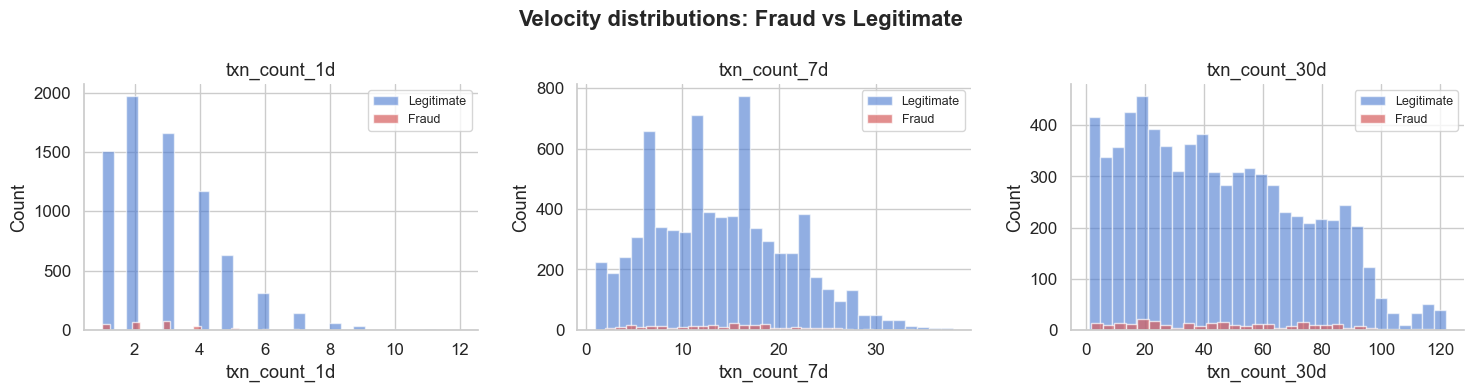

In [6]:
# Visualise velocity distributions: fraud vs legitimate
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['txn_count_1d', 'txn_count_7d', 'txn_count_30d']):
    axes[i].hist(df[df['is_fraud']==0][col], bins=30, alpha=0.6,
                 color=COLORS[0], label='Legitimate', edgecolor='white')
    axes[i].hist(df[df['is_fraud']==1][col], bins=30, alpha=0.7,
                 color=COLORS[3], label='Fraud', edgecolor='white')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].set_title(col)
    axes[i].legend(fontsize=9)

plt.suptitle('Velocity distributions: Fraud vs Legitimate', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

## 6. Behavioural Features

These features capture sudden changes in a user's behaviour —
the strongest indicators of account takeover fraud.

- `device_changed` — did the user switch device from their last transaction?
- `location_changed` — did the user switch city from their last transaction?
- `time_since_last_txn_hrs` — hours since this user's previous transaction.
  Very short gaps (seconds between transactions) signal automated fraud.
  Very long gaps (dormant account suddenly active) also signal risk.

`shift(1)` within each user group gives previous row's value.
First transaction per user gets NaN from shift — filled with 0 (no change).

In [7]:
# Previous device and location per user
df['prev_device']   = df.groupby('user_id')['device'].shift(1)
df['prev_location'] = df.groupby('user_id')['location'].shift(1)
df['prev_timestamp']= df.groupby('user_id')['timestamp'].shift(1)

# Device changed: current != previous, and previous is not NaN
df['device_changed'] = (
    (df['device'] != df['prev_device']) &
    df['prev_device'].notna()
).astype(int)

# Location changed: current != previous, and previous is not NaN
df['location_changed'] = (
    (df['location'] != df['prev_location']) &
    df['prev_location'].notna()
).astype(int)

# Time since last transaction in hours
df['time_since_last_txn_hrs'] = (
    (df['timestamp'] - df['prev_timestamp'])
    .dt.total_seconds() / 3600
)

# Fill NaN for first transaction per user (no previous txn exists)
df['device_changed'].fillna(0, inplace=True)
df['location_changed'].fillna(0, inplace=True)
df['time_since_last_txn_hrs'].fillna(0, inplace=True)

# Drop helper columns
df.drop(columns=['prev_device', 'prev_location', 'prev_timestamp'], inplace=True)

behavioural_cols = ['device_changed','location_changed','time_since_last_txn_hrs']
print('Behavioural features added:', behavioural_cols)
print()

# Verify: fraud should have higher device/location change rates
print('Device change rate by label:')
print(df.groupby('is_fraud')['device_changed'].mean().rename({0:'Legitimate', 1:'Fraud'}).to_string())
print()
print('Location change rate by label:')
print(df.groupby('is_fraud')['location_changed'].mean().rename({0:'Legitimate', 1:'Fraud'}).to_string())

Behavioural features added: ['device_changed', 'location_changed', 'time_since_last_txn_hrs']

Device change rate by label:
is_fraud
Legitimate   0.7230
Fraud        0.8308

Location change rate by label:
is_fraud
Legitimate   0.7652
Fraud        0.8120


## 7. Missing Value Flags

Rather than imputing missing `location` and `device` values,
i explicitly flag them as binary features.

**Why flag instead of drop or impute?**
Missingness is informative — from the EDA, legitimate transactions almost
always have a location and device. A missing value is itself a signal.
Flagging preserves that signal while allowing to fill the NaN for encoding.

In [8]:
# Binary flag: 1 if the field was missing in the original log
df['location_missing'] = df['location'].isna().astype(int)
df['device_missing']   = df['device'].isna().astype(int)

print('Missing value flags added.')
print()
print('location_missing rate by label:')
print(df.groupby('is_fraud')['location_missing'].mean().rename({0:'Legitimate', 1:'Fraud'}).to_string())
print()
print('device_missing rate by label:')
print(df.groupby('is_fraud')['device_missing'].mean().rename({0:'Legitimate', 1:'Fraud'}).to_string())

Missing value flags added.

location_missing rate by label:
is_fraud
Legitimate   0.1088
Fraud        0.5677

device_missing rate by label:
is_fraud
Legitimate   0.1383
Fraud        0.1617


## 8. Categorical Encoding

model requires numeric inputs. convert categorical columns to integer codes.

Use pandas `category` dtype with `.cat.codes` — this assigns a stable
integer to each unique value (e.g. 'cashout'=0, 'debit'=1, etc.).

Missing values in `location` and `device` are filled with `'unknown'`
before encoding so they get their own code rather than -1.

In [9]:
# Fill NaN in categoricals before encoding
# 'unknown' becomes its own category code
df['location']   = df['location'].fillna('unknown')
df['device']     = df['device'].fillna('unknown')
df['currency']   = df['currency'].fillna('unknown')

# Encode each categorical column
cat_cols = ['txn_type', 'location', 'device', 'log_format', 'currency']

for col in cat_cols:
    encoded_col = col + '_encoded'
    df[encoded_col] = df[col].astype('category').cat.codes
    print('{:<20} -> {}  | {} unique values'.format(
        col, encoded_col, df[col].nunique()
    ))

print()
print('Category mappings (txn_type):')
mapping = dict(enumerate(df['txn_type'].astype('category').cat.categories))
for code, label in mapping.items():
    print('  {} -> {}'.format(code, label))

txn_type             -> txn_type_encoded  | 8 unique values
location             -> location_encoded  | 8 unique values
device               -> device_encoded  | 7 unique values
log_format           -> log_format_encoded  | 7 unique values
currency             -> currency_encoded  | 4 unique values

Category mappings (txn_type):
  0 -> cashout
  1 -> debit
  2 -> deposit
  3 -> purchase
  4 -> refund
  5 -> top-up
  6 -> transfer
  7 -> withdrawal


## 9. Feature Matrix Summary

Overview of all features built, grouped by type.

In [10]:
feature_groups = {
    'Temporal'      : ['hour','day_of_week','is_night','is_weekend','is_business_hours'],
    'Amount'        : ['amount','amount_z_score','is_high_amount','amount_vs_user_max',
                        'user_mean_amount','user_std_amount','user_max_amount'],
    'Velocity'      : ['txn_count_1d','txn_sum_1d','txn_count_7d',
                        'txn_sum_7d','txn_count_30d','txn_sum_30d'],
    'Behavioural'   : ['device_changed','location_changed','time_since_last_txn_hrs'],
    'Missing flags' : ['location_missing','device_missing'],
    'Encoded cats'  : ['txn_type_encoded','location_encoded','device_encoded',
                        'log_format_encoded','currency_encoded'],
}

total_features = 0
print('=' * 50)
print('  FEATURE MATRIX SUMMARY')
print('=' * 50)
for group, cols in feature_groups.items():
    print('  {:<16}: {} features'.format(group, len(cols)))
    for c in cols:
        print('    - {}'.format(c))
    total_features += len(cols)
print('=' * 50)
print('  Total features  :', total_features)
print('  Total rows      :', len(df))
print('  Label (is_fraud):', df['is_fraud'].sum(), 'fraud /', (df['is_fraud']==0).sum(), 'legitimate')
print('=' * 50)

  FEATURE MATRIX SUMMARY
  Temporal        : 5 features
    - hour
    - day_of_week
    - is_night
    - is_weekend
    - is_business_hours
  Amount          : 7 features
    - amount
    - amount_z_score
    - is_high_amount
    - amount_vs_user_max
    - user_mean_amount
    - user_std_amount
    - user_max_amount
  Velocity        : 6 features
    - txn_count_1d
    - txn_sum_1d
    - txn_count_7d
    - txn_sum_7d
    - txn_count_30d
    - txn_sum_30d
  Behavioural     : 3 features
    - device_changed
    - location_changed
    - time_since_last_txn_hrs
  Missing flags   : 2 features
    - location_missing
    - device_missing
  Encoded cats    : 5 features
    - txn_type_encoded
    - location_encoded
    - device_encoded
    - log_format_encoded
    - currency_encoded
  Total features  : 28
  Total rows      : 7774
  Label (is_fraud): 266 fraud / 7508 legitimate


## 10. Correlation with Fraud Label

Rank all numeric features by their absolute correlation with `is_fraud`.
This gives a first indication of which features are most predictive
before the model even runs — and flags any features with near-zero signal.

In [11]:
# Collect all engineered feature columns
all_feature_cols = (
    feature_groups['Temporal'] +
    feature_groups['Amount'] +
    feature_groups['Velocity'] +
    feature_groups['Behavioural'] +
    feature_groups['Missing flags'] +
    feature_groups['Encoded cats']
)

# Correlation with is_fraud, sorted by absolute value
corr_with_label = (
    df[all_feature_cols + ['is_fraud']]
    .corr()['is_fraud']
    .drop('is_fraud')
    .abs()
    .sort_values(ascending=False)
)

print('Top 15 features by correlation with is_fraud:')
print(corr_with_label.head(15).to_string())
print()
print('Bottom 5 features (weakest signal):')
print(corr_with_label.tail(5).to_string())

Top 15 features by correlation with is_fraud:
is_high_amount       0.3813
amount_z_score       0.2579
amount_vs_user_max   0.2573
amount               0.2572
location_missing     0.2526
is_night             0.1646
location_encoded     0.1477
hour                 0.1154
txn_sum_1d           0.0804
is_business_hours    0.0778
device_changed       0.0440
log_format_encoded   0.0238
txn_sum_7d           0.0209
location_changed     0.0201
txn_type_encoded     0.0197

Bottom 5 features (weakest signal):
txn_count_7d       0.0026
user_mean_amount   0.0018
txn_count_1d       0.0012
user_max_amount    0.0005
currency_encoded   0.0003


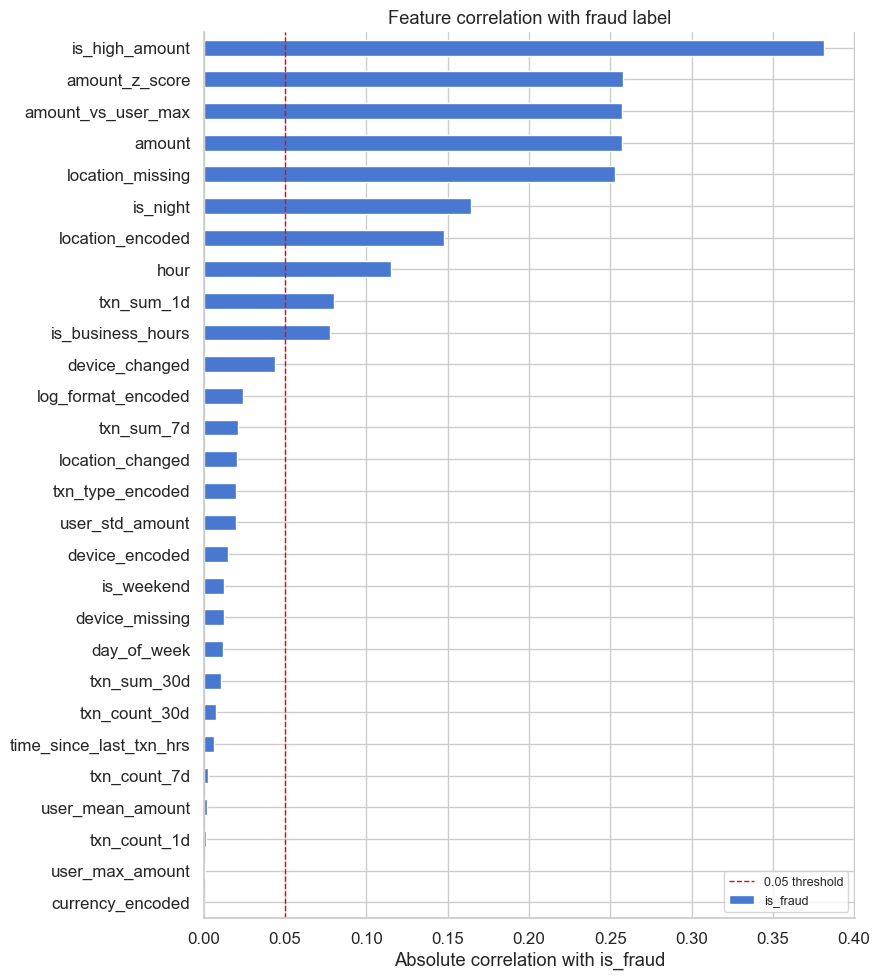

In [12]:
# Horizontal bar chart of feature correlations
fig, ax = plt.subplots(figsize=(9, 10))
corr_with_label.sort_values().plot.barh(ax=ax, color=COLORS[0], edgecolor='white')
ax.set_xlabel('Absolute correlation with is_fraud')
ax.set_title('Feature correlation with fraud label')
ax.axvline(0.05, color='red', linestyle='--', linewidth=1, label='0.05 threshold')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

## 11. Missing Values Check


In [13]:
feature_nulls = df[all_feature_cols].isnull().sum()
feature_nulls = feature_nulls[feature_nulls > 0]

if len(feature_nulls) == 0:
    print('No missing values in feature matrix.')
else:
    print('Columns with missing values:')
    print(feature_nulls.to_string())

No missing values in feature matrix.


## 12. Save Feature Matrix

Saved the full dataframe including all original columns, engineered features,
and the `is_fraud` label.

The modelling notebook will select only the feature columns for training.

In [14]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)

# Verify the saved file
verify = pd.read_csv(OUTPUT_PATH)

print('Saved to  :', OUTPUT_PATH)
print('File size : {:.1f} KB'.format(OUTPUT_PATH.stat().st_size / 1024))
print('Shape     :', verify.shape)
print('Columns   :', len(verify.columns))
print()
print('All columns:')
for i, col in enumerate(verify.columns):
    print('  {:>2}. {}'.format(i+1, col))

Saved to  : ..\data\processed\features.csv
File size : 1989.4 KB
Shape     : (7774, 36)
Columns   : 36

All columns:
   1. timestamp
   2. user_id
   3. txn_type
   4. amount
   5. currency
   6. location
   7. device
   8. log_format
   9. is_fraud
  10. hour
  11. day_of_week
  12. is_night
  13. is_weekend
  14. is_business_hours
  15. user_mean_amount
  16. user_std_amount
  17. user_max_amount
  18. amount_z_score
  19. is_high_amount
  20. amount_vs_user_max
  21. txn_count_1d
  22. txn_sum_1d
  23. txn_count_7d
  24. txn_sum_7d
  25. txn_count_30d
  26. txn_sum_30d
  27. device_changed
  28. location_changed
  29. time_since_last_txn_hrs
  30. location_missing
  31. device_missing
  32. txn_type_encoded
  33. location_encoded
  34. device_encoded
  35. log_format_encoded
  36. currency_encoded

Next step -> 05_modelling.ipynb
